### 1 条形图

<BarContainer object of 6 artists>

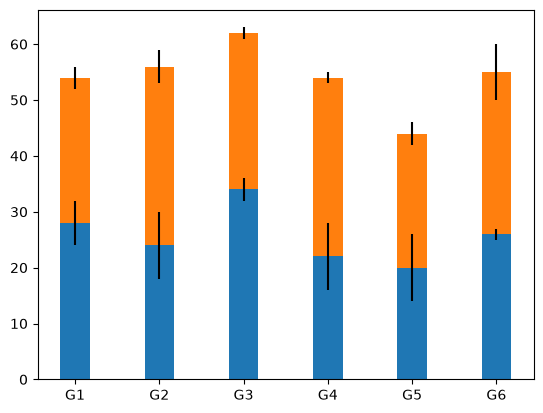

In [3]:
import numpy as np
import matplotlib.pyplot as plt
labels = ['G1','G2','G3','G4','G5','G6'] #级别
men_means = np.random.randint(20,35,size=6) #平均值
women_means = np.random.randint(20,35,size=6)
men_std = np.random.randint(1,7,size=6) #标准差
women_std = np.random.randint(1,7,size=6)
w = 0.35 #条形图宽度(width)

#堆叠柱状图
plt.bar(labels,men_means,width=w,yerr=men_std)

plt.bar(labels,women_means,w,bottom=men_means,yerr=women_std) #男平均数做底

C:\Users\jm166\AppData\Local\Temp\ipykernel_16024\1369456265.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


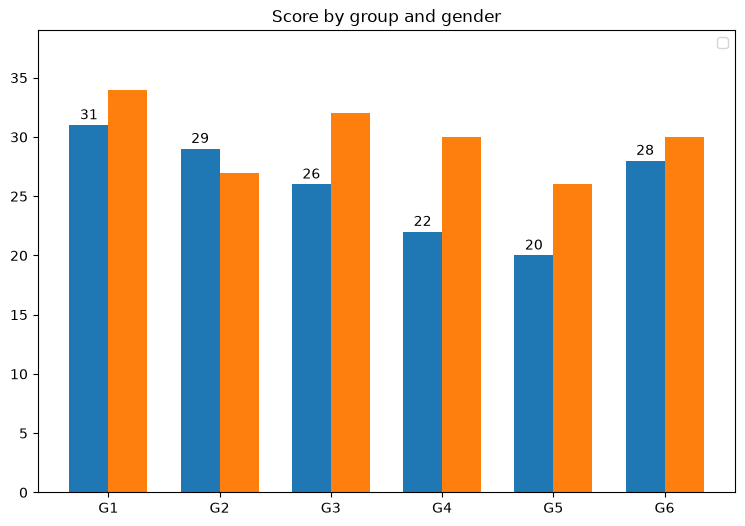

In [4]:
labels = ['G1','G2','G3','G4','G5','G6'] #级别
x = np.arange(6)
men_means = np.random.randint(20,35,size=6) #平均值
women_means = np.random.randint(20,35,size=6)
men_std = np.random.randint(1,7,size=6) #标准差
women_std = np.random.randint(1,7,size=6)
w = 0.35 #条形图宽度(width)

#分组带标签柱状图
plt.figure(figsize=(9,6))
plt.bar(x-w/2,men_means,width=w)
plt.bar(x+w/2,women_means,w)
_ = plt.xticks(x,labels)
for i in range(6):
    plt.text(i-w/2,men_means[i]+0.5,men_means[i],horizontalalignment='center') 

plt.ylim(0,np.concatenate([men_means,women_means]).max()+5)
plt.title('Score by group and gender')
plt.legend()

### 2 极坐标图

Text(0.5, 1.0, 'A line plot on a polar axis')

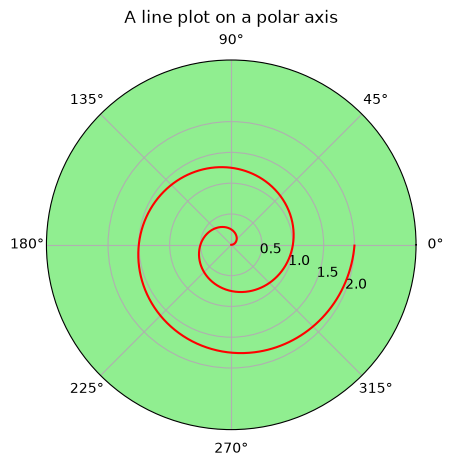

In [5]:
r = np.arange(0,4*np.pi,0.01) #弧度值
y = np.linspace (0,2,len(r)) #目标值

ax = plt.subplot(111,projection='polar',facecolor='lightgreen')
ax.plot(r,y,color='red')
ax.set_rmax(3) #设置半径最大值
ax.set_rticks([0.5,1,1.5,2]) #设置半径刻度
ax.set_rlabel_position(-22.5) #设置半径刻度位置
ax.grid(True) #网格线

ax.set_title("A line plot on a polar axis",va='center',ha='center',pad=30)

<BarContainer object of 8 artists>

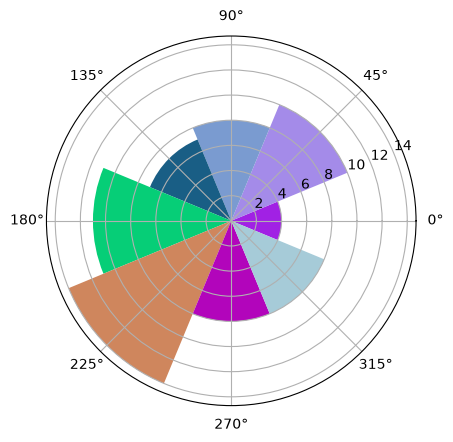

In [6]:
#极坐标条形图
N = 8 #分成8份
theta = np.linspace(0.0,2*np.pi,N,endpoint=False)
radii = np.random.randint(3,15,size=N)
width = np.pi/4
colors = np.random.rand(8,3) #随机生成颜色
ax = plt.subplot(111,projection='polar') #polar表示极坐标
ax.bar(theta,radii,width=width,bottom=0.0,color=colors)

### 3 箱型图

C:\Users\jm166\AppData\Local\Temp\ipykernel_16024\3738179934.py:7: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  _ = plt.boxplot(data,1,tick_labels=labels, sym='gD') #红色的圆点是异常值


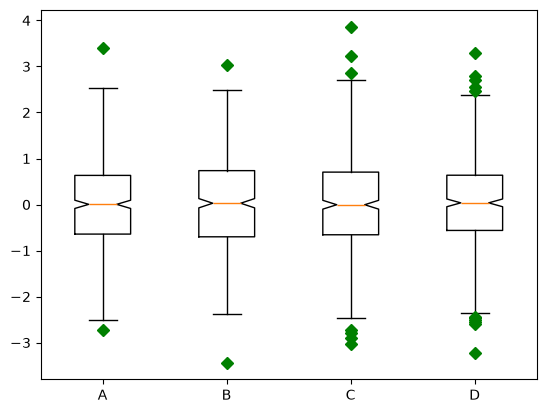

In [7]:
import matplotlib.pyplot as plt
import numpy as np

data = np.random.normal(size=(500, 4))
labels = ['A', 'B', 'C', 'D']

_ = plt.boxplot(data,1,tick_labels=labels, sym='gD') #红色的圆点是异常值
plt.show()


### 4 散点图

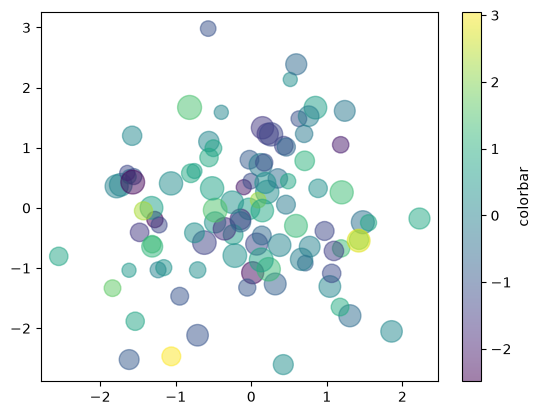

In [8]:
data = np.random.randn(100,2) #标准正态分布
s = np.random.randint(100,300,size=100) #尺寸大小
color = np.random.randn(100)
plt.scatter(data[:,0], #横坐标(x)
            data[:,1], #纵坐标(y)
            s = s, #尺寸
            c = color, #颜色
            alpha = 0.5) #透明度
cb = plt.colorbar() #色柱
#cb.set_ticks(np.linspace(0,1,8))
#cb.set_ticklabels(np.arange(-4,4))
cb.set_label('colorbar')

### 5 饼图

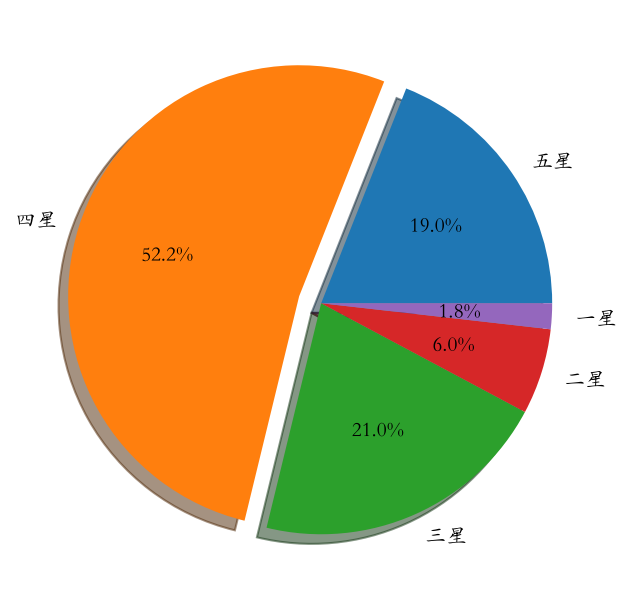

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#解决中文字体乱码的问题
plt.rcParams['font.sans-serif'] = 'STKaiti'

labels = ["五星","四星","三星","二星","一星"] #标签
percent = [95,261,105,30,9] #某市星级酒店数量

#设置图片大小和分辨率
fig = plt.figure(figsize=(5,5),dpi=150)

#偏移中心量，突出一部分
explode = (0,0.1,0,0,0)

#绘制饼图：autopct显示百分比，这里保留一位小数；shadow控制是否显示阴影
plt.pie(x = percent, #数据
        explode = explode, #偏移中心量
        labels = labels, #显示标签
        autopct = '%0.1f%%', #显示百分比
        shadow = True) #阴影，3D效果
plt.savefig("./饼图.jpg")

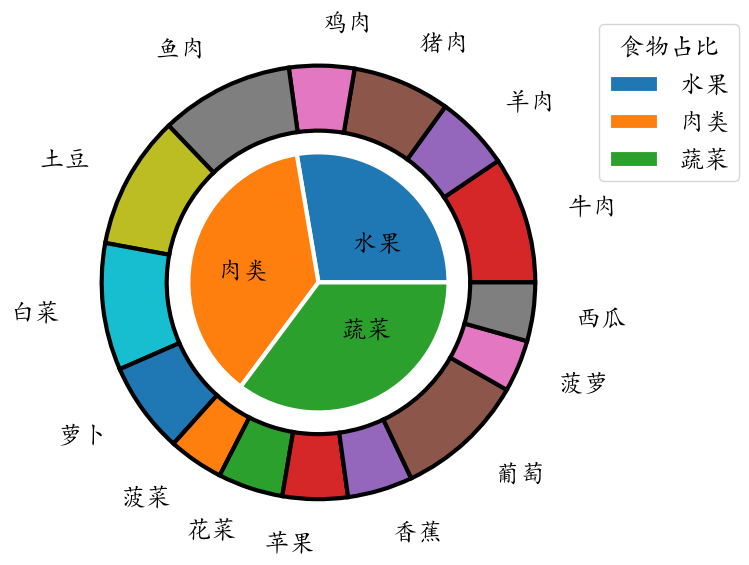

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
food = pd.read_excel('./food.xlsx')

#分组聚合，内圈数据
inner = food.groupby(by='type')['花费'].sum()
outer = food['花费'] #外圈数据
plt.rcParams['font.family'] = 'Kaiti'
plt.rcParams['font.size'] = 18
fig = plt.figure(figsize=(8,8))

#绘制内部饼图
plt.pie(x = inner, #数据
        radius = 0.6, #饼图半径
        wedgeprops = dict(linewidth=3,width=0.6,edgecolor='w'), #饼图格式：间隔线宽，饼图宽度，边界颜色
        labels = inner.index, #显示标签
        labeldistance = 0.4) #标签位置

#绘制外部饼图
plt.pie(x = outer, #数据
        radius = 1, #饼图半径
        wedgeprops = dict(linewidth=3,width=0.3,edgecolor='k'), #饼图格式：间隔线宽，饼图宽度，边界颜色
        labels = food['食材'], #显示标签
        labeldistance = 1.2) #标签位置

#设置图例位置，bbox_to_anchor = (x,y,width,height) 控制图例显示位置
plt.legend(inner.index,bbox_to_anchor = (0.9,0.6,0.4,0.4),title = '食物占比')
plt.tight_layout()
plt.savefig('./嵌套饼图.png',dpi=200)

### 6 热力图

In [11]:
rose = plt.imread('./rose.jpg')
display(rose.shape,rose) #高度555行，宽度610列，对应着长度为3的像素

(555, 610, 3)

array([[[246, 246, 246],
        [246, 246, 246],
        [246, 246, 246],
        ...,
        [246, 246, 246],
        [246, 246, 246],
        [246, 246, 246]],

       [[246, 246, 246],
        [246, 246, 246],
        [246, 246, 246],
        ...,
        [246, 246, 246],
        [246, 246, 246],
        [246, 246, 246]],

       [[246, 246, 246],
        [246, 246, 246],
        [246, 246, 246],
        ...,
        [246, 246, 246],
        [246, 246, 246],
        [246, 246, 246]],

       ...,

       [[246, 246, 246],
        [246, 246, 246],
        [246, 246, 246],
        ...,
        [246, 246, 246],
        [246, 246, 246],
        [246, 246, 246]],

       [[246, 246, 246],
        [246, 246, 246],
        [246, 246, 246],
        ...,
        [246, 246, 246],
        [246, 246, 246],
        [246, 246, 246]],

       [[246, 246, 246],
        [246, 246, 246],
        [246, 246, 246],
        ...,
        [246, 246, 246],
        [246, 246, 246],
        [246, 246, 246]]

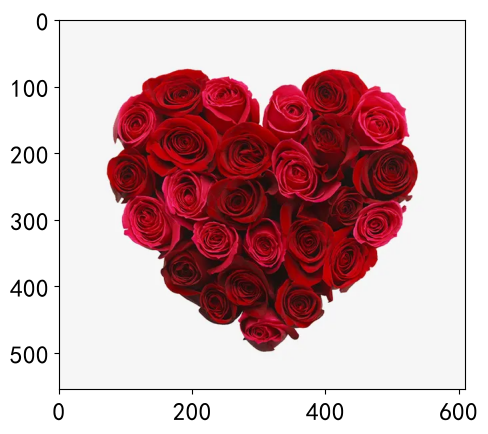

In [12]:
plt.imshow(rose)

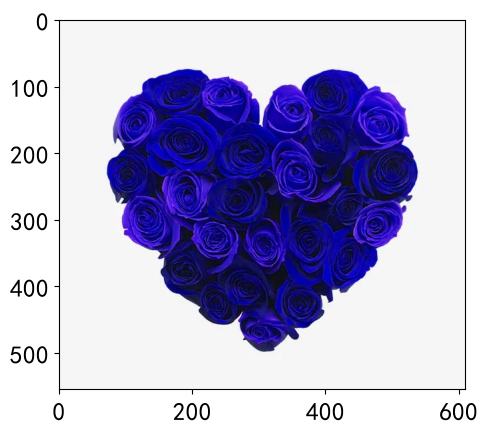

In [13]:
#蓝色玫瑰
plt.imshow(rose[:,:,::-1])

findfont: Failed to find font weight heavy for KaiTi, now using 400.


Text(0.5, 1.0, 'Harvest of local farmers (in tons/years)')

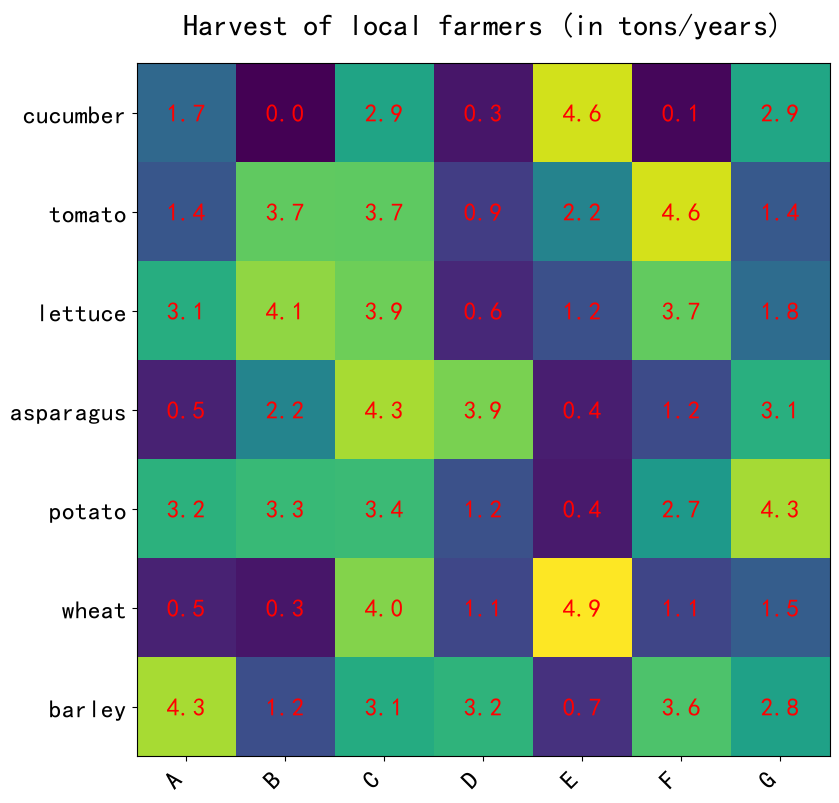

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

vegetables = ["cucumber","tomato","lettuce","asparagus","potato","wheat","barley"]
farmers = list('ABCDEFG')

harvest = np.random.rand(7,7)*5 #农民丰收数据

plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'heavy'
plt.figure(figsize=(9,9))
im = plt.imshow(harvest)

plt.xticks(np.arange(len(farmers)),farmers,rotation=45,ha='right')
plt.yticks(np.arange(len(vegetables)),vegetables)

#绘制文本
for i in range(len(vegetables)):
    for j in range(len(farmers)):
        text = plt.text(j,i,round(harvest[i,j],1),
                        ha="center",va="center",color='r')
plt.title("Harvest of local farmers (in tons/years)",pad=20)

### 7 数据分析师岗位分析

#### 7.1 各城市对数据分析岗位的需求量

In [1]:
import pandas as pd
job = pd.read_csv('./job_process.csv')
job.head()

,index,positionName,companyShortName,city,companySize,education,financeStage,industryField,salary,workYear,hitags,companyLabelList,job_detail,Python,SQL,Tableau,Excel,SPSS/SAS
0,0,高级数据分析师,拉勾网,北京,500-2000人,本科,D轮及以上,企业服务,30.0,5-10年,"[""免费下午茶"",""ipo倒计时"",""bat背景"",""地铁周边"",""每天管两餐"",""定期团建...","[""五险一金"",""弹性工作"",""带薪年假"",""免费两餐""]",\n1.搭建数据指标框架，完整并准确反映业务趋势和变化，及时发现和定位问题\n2.独立完成数...,1,1,0,0,0
1,1,数据分析师,OK Group,北京,500-2000人,大专,B轮,金融,35.0,5-10年,NaN,"[""节日礼物"",""年度旅游"",""扁平管理"",""领导好""]",\n工作职责：\n1. 负责建立交易平台日常分析体系，包括核心指标体系、报表体系，专题活动分...,0,1,0,0,0
2,2,高级数据分析师,金山办公软件,北京,2000人以上,本科,上市公司,移动互联网,20.0,3-5年,NaN,"[""年底双薪"",""节日礼物"",""技能培训"",""绩效奖金""]",\n职位描述：1.对亿计的办公用户数据进行深度挖掘，引导产品、运营，并能实际应用到业务中带来...,1,1,0,0,0
3,3,数据分析师,金山办公软件,北京,2000人以上,本科,上市公司,移动互联网,20.0,1-3年,NaN,"[""年底双薪"",""节日礼物"",""技能培训"",""绩效奖金""]",\n工作职责：-负责日常运营、业务数据等分析-针对产品需求做深入的数据分析报告，分析用户行为...,0,1,0,0,1
4,4,数据分析师,京东集团,北京,2000人以上,本科,上市公司,电商,22.5,3-5年,"[""免费班车"",""免费体检"",""地铁周边""]","[""五险一金"",""带薪年假"",""免费班车"",""定期体检""]",\n【数据分析师岗】\n岗位要求：\n1、构建及维护客户体验相关数据报表平台；\n2、与大数...,0,1,1,1,1


findfont: Failed to find font weight heavy for KaiTi, now using 400.
findfont: Failed to find font weight bold for KaiTi, now using 400.


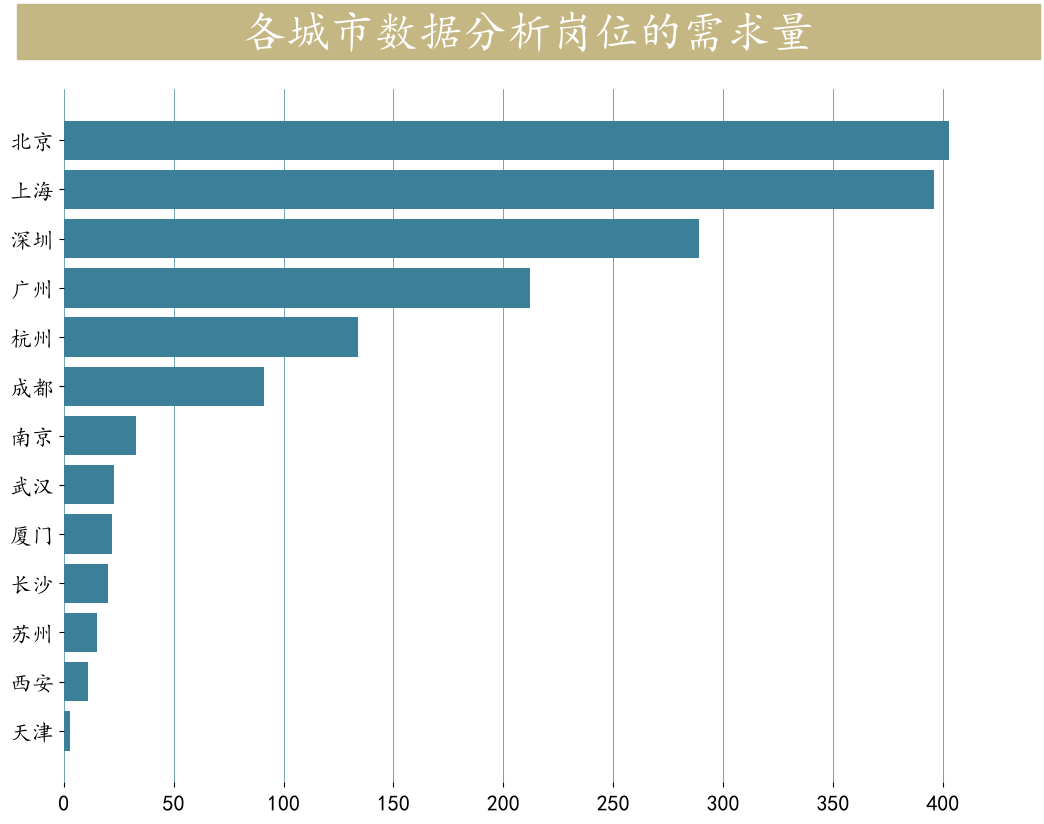

In [15]:
plt.figure(figsize=(12,9))
cities = job['city'].value_counts() #统计城市工作数量

plt.barh(y = cities.index[::-1],
         width = cities.values[::-1],
         color = '#3c7f99')

plt.box(False) #不显示边框
plt.title(label='          各城市数据分析岗位的需求量          ',
          fontsize=32,weight='bold',color='white',
          backgroundcolor='#c5b783',pad=30)
plt.tick_params(labelsize=16)
plt.grid(axis='x',linewidth=0.5,color='#3c7f99')

#### 7.2 不同领域对数据分析岗位的需求

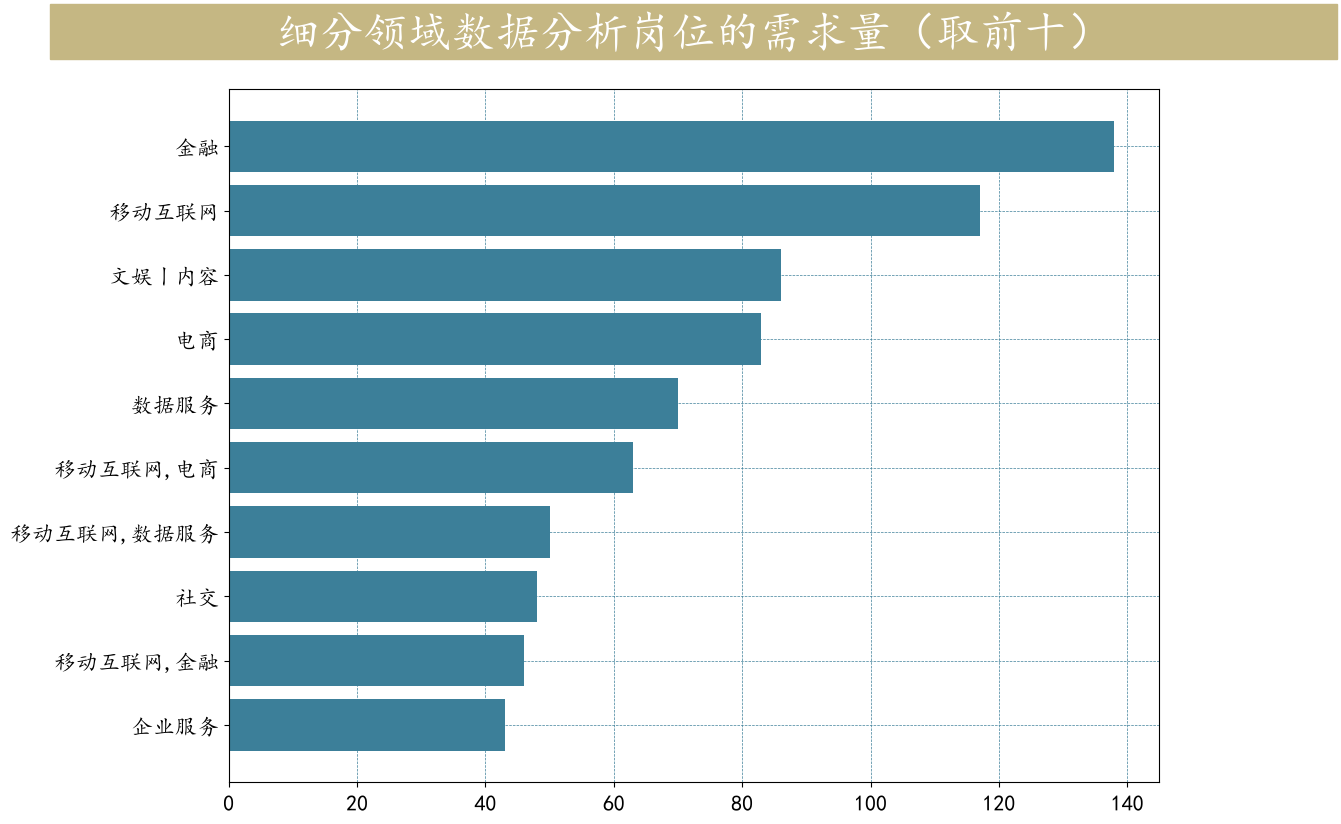

In [17]:
#获取需求量前十多的领域
industry_index = job["industryField"].value_counts()[:10].index
industry = job.loc[job["industryField"].isin(industry_index),"industryField"]

field = job["industryField"].value_counts()[:10]

plt.figure(figsize=(12,9))
plt.barh(y = field.index[::-1],
         width = field.values[::-1],
         color = '#3c7f99')
plt.title(label='          细分领域数据分析岗位的需求量（取前十）          ',
          fontsize=32,weight='bold',color='white',
          backgroundcolor='#c5b783',ha='center',pad=30)
plt.tick_params(labelsize=16)
plt.grid(lw=0.5,color='#3c7f99',ls='--')

#### 7.3 各城市薪资情况

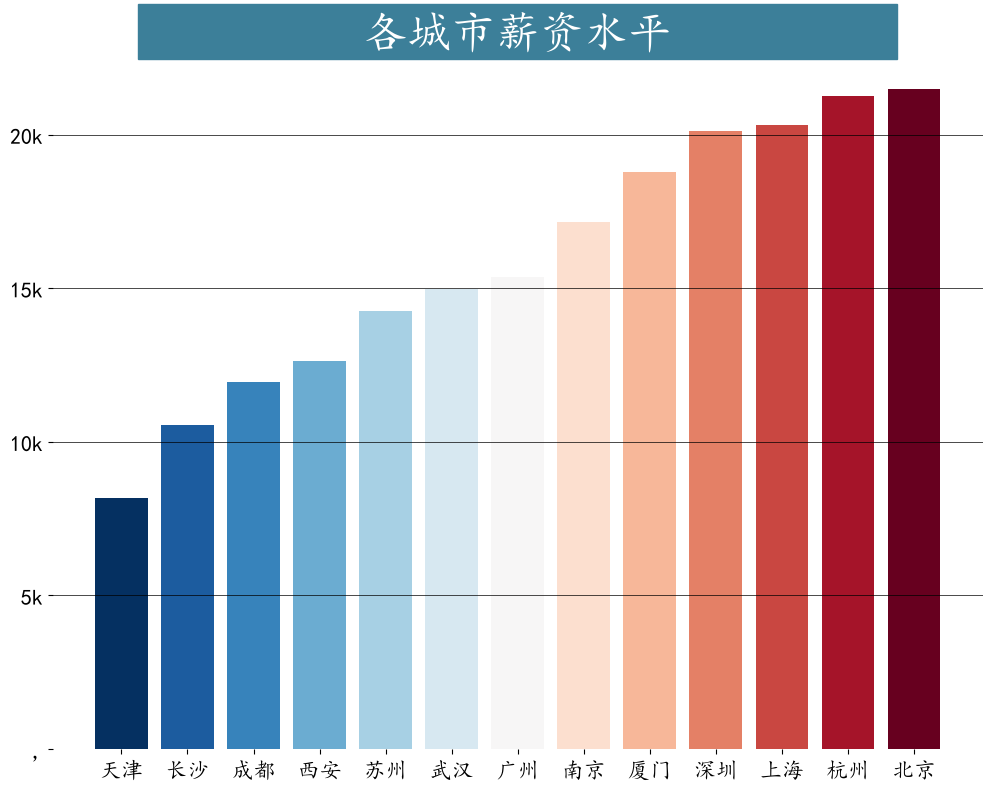

In [19]:
plt.figure(figsize=(12,9))
city_salary = job.groupby("city")["salary"].mean().sort_values() #分组聚合运算

plt.bar(x = city_salary.index,height = city_salary.values,
        color = plt.cm.RdBu_r(np.linspace(0,1,len(city_salary))))
plt.title(label='          各城市薪资水平          ',
          fontsize=32,weight='bold',color='white',backgroundcolor='#3c7f99')
plt.tick_params(labelsize=16)
plt.grid(axis='y',linewidth=0.5,color='k')
plt.yticks(ticks = np.arange(0,25,step=5),labels=[',','5k','10k','15k','20k'])
plt.box(False) #去掉边框
plt.savefig('./各城市薪资情况.png')